# Implementasi SVM untuk Klasifikasi Kelayakan PKH
## Dataset Real — 3 Desa Kecamatan Kasimbar

**Deskripsi:** Notebook ini melakukan training model SVM untuk mengklasifikasikan
kelayakan calon penerima bantuan Program Keluarga Harapan (PKH) berdasarkan
8 atribut sosial-ekonomi menggunakan **dataset real** dari pendamping PKH.

### Perubahan dari Versi Sebelumnya (v2 → v3):
- ✅ Dataset real (bukan sintetis) — 318 data dari 3 desa
- ✅ Encoding ordinal manual 1-5 (bukan LabelEncoder)
- ✅ MinMaxScaler (bukan StandardScaler)
- ✅ Export dictionary (bukan class SVMPipeline)
- ✅ ROC Curve + AUC Score

**Output:** Model SVM (.pkl) siap integrasi ke web SPK Flask

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
import json

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay,
                             roc_curve, auc, roc_auc_score)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load Dataset Real

Dataset berasal dari pendamping PKH di 3 desa Kecamatan Kasimbar:
- Posona (165 data)
- Kasimbar Palapi (112 data)
- Posona Atas (41 data)

Total: **318 data** dengan label status kelayakan (Layak/Tidak Layak).

In [2]:
# Load dataset dari Kaggle dataset
# Dataset: aamirulmaulana/dataset-real

desa_files = {
    'POSONA': '/kaggle/input/datasets/aamirulmaulana/dataset-pkh/POSONA.csv',
    'KASIMBAR PALAPI': '/kaggle/input/datasets/aamirulmaulana/dataset-pkh/KASIMBAR-PALAPI.csv',
    'POSONA ATAS': '/kaggle/input/datasets/aamirulmaulana/dataset-pkh/POSONA-ATAS.csv',
}

df_list = []
for desa, path in desa_files.items():
    d = pd.read_csv(path)
    d['DESA'] = desa
    df_list.append(d)

df_raw = pd.concat(df_list, ignore_index=True)
print(f'Total dataset: {len(df_raw)} data dari 3 desa')
print(f'Posona: {(df_raw["DESA"]=="POSONA").sum()} data')
print(f'Kasimbar Palapi: {(df_raw["DESA"]=="KASIMBAR PALAPI").sum()} data')
print(f'Posona Atas: {(df_raw["DESA"]=="POSONA ATAS").sum()} data')

Total dataset: 318 data dari 3 desa
Posona: 165 data
Kasimbar Palapi: 112 data
Posona Atas: 41 data


## 3. Pembersihan Data

Dataset real memiliki beberapa masalah kecil yang perlu dibersihkan:
1. **Trailing space** pada kolom STATUS (`"Layak "` → `"Layak"`)
2. **Case inconsistency** pada kolom ASET (ada yang `"Memiliki..."` ada yang `"memiliki..."`)
3. **Mapping** semua nilai ke format yang konsisten

In [3]:
# 1. Bersihkan trailing space di STATUS
df_raw['STATUS'] = df_raw['STATUS'].str.strip()
print(f'Distribusi STATUS setelah cleanup:')
print(df_raw['STATUS'].value_counts())
print()

# 2. Standardisasi format ASET (Title Case)
df_raw['ASET'] = df_raw['ASET'].str.strip().str.title()
print('Distribusi ASET setelah Title Case:')
print(df_raw['ASET'].value_counts())
print()

# 3. Cek tidak ada missing values
print('Missing values:')
print(df_raw.isnull().sum())

Distribusi STATUS setelah cleanup:
STATUS
Layak          196
Tidak Layak    122
Name: count, dtype: int64

Distribusi ASET setelah Title Case:
ASET
Memiliki Motor Dengan Harga Jual Rendah    104
Memiliki Mobil Atau Tanah/Kebun             68
Memiliki Motor Dengan Harga Jual Tinggi     62
Tidak Memiliki Aset                         50
Memiliki Mobil Dan Tanah/Kebun              34
Name: count, dtype: int64

Missing values:
KEPALA KELUARGA    0
NIK                0
PENGHASILAN        0
PEKERJAAN          0
ASET               0
HAMIL              0
AUD                0
ANAK SEKOLAH       0
DISABILITAS        0
LANSIA             0
STATUS             0
DESA               0
dtype: int64


## 4. Mapping Ordinal Encoding

Berdasarkan dokumen resmi dari **Zainal — Ketua Tim SDM PKH Provinsi Sulawesi Tengah**
(Keputusan Dirjen Linjamsos No. 9/3/HK.01.1/2025):

### Penghasilan (Bobot 25%)
| Skor | Kategori | Rentang |
|------|----------|---------|
| 5 | Desil 1 | < Rp.500.000 |
| 4 | Desil 2 | Rp.600.000 - Rp.700.000 |
| 3 | Desil 3 | Rp.800.000 - Rp.900.000 |
| 2 | Desil 4 | Rp.1.000.000 - Rp.1.200.000 |
| 1 | Desil 5 | Rp.1.300.000 - Rp.1.500.000 |

### Pekerjaan (Bobot 20%)
| Skor | Kategori |
|------|----------|
| 5 | Tidak Bekerja |
| 4 | Pekerja Bebas |
| 3 | Petani/Nelayan |
| 2 | Wiraswasta |
| 1 | PNS/Pegawai Tetap |

### Kepemilikan Aset (Bobot 15%)
| Skor | Kategori |
|------|----------|
| 5 | Tidak Memiliki Aset |
| 4 | Memiliki Motor Dengan Harga Jual Rendah |
| 3 | Memiliki Motor Dengan Harga Jual Tinggi |
| 2 | Memiliki Mobil Atau Tanah/Kebun |
| 1 | Memiliki Mobil Dan Tanah/Kebun |

### Komponen Sosial (Biner 0/1)
- Ibu Hamil: Ada=1, Tidak=0 (Bobot 10%)
- Anak Usia Dini: Ada=1, Tidak=0 (Bobot 10%)
- Anak Sekolah: Ada=1, Tidak=0 (Bobot 10%)
- Disabilitas: Ada=1, Tidak=0 (Bobot 5%)
- Lansia: Ada=1, Tidak=0 (Bobot 5%)

In [4]:
# ─── Ordinal Mapping (sesuai dokumen resmi) ───

penghasilan_map = {
    'Desil 1': 5,
    'Desil 2': 4,
    'Desil 3': 3,
    'Desil 4': 2,
    'Desil 5': 1,
}

pekerjaan_map = {
    'Tidak Bekerja': 5,
    'Pekerja Bebas': 4,
    'Petani/Nelayan': 3,
    'Wiraswasta': 2,
    'PNS/Pegawai Tetap': 1,
}

aset_map = {
    'Tidak Memiliki Aset': 5,
    'Memiliki Motor Dengan Harga Jual Rendah': 4,
    'Memiliki Motor Dengan Harga Jual Tinggi': 3,
    'Memiliki Mobil Atau Tanah/Kebun': 2,
    'Memiliki Mobil Dan Tanah/Kebun': 1,
}

boolean_map = {
    'Ada': 1,
    'Tidak Ada': 0,
}

# ─── Terapkan mapping ───
df = df_raw.copy()

df['skor_penghasilan'] = df['PENGHASILAN'].map(penghasilan_map)
df['skor_pekerjaan'] = df['PEKERJAAN'].map(pekerjaan_map)
df['skor_aset'] = df['ASET'].map(aset_map)
df['skor_ibu_hamil'] = df['HAMIL'].map(boolean_map)
df['skor_aud'] = df['AUD'].map(boolean_map)
df['skor_anak_sekolah'] = df['ANAK SEKOLAH'].map(boolean_map)
df['skor_disabilitas'] = df['DISABILITAS'].map(boolean_map)
df['skor_lansia'] = df['LANSIA'].map(boolean_map)

# Target: 1=Layak, 0=Tidak Layak
df['label'] = df['STATUS'].map({'Layak': 1, 'Tidak Layak': 0})

# Cek apakah ada nilai yang tidak ter-mapping
print('Nilai unik setelah mapping:')
skor_cols = ['skor_penghasilan', 'skor_pekerjaan', 'skor_aset',
             'skor_ibu_hamil', 'skor_aud', 'skor_anak_sekolah',
             'skor_disabilitas', 'skor_lansia']
for col in skor_cols:
    print(f'{col}: {df[col].unique()}')

print(f'\nLabel: {df["label"].unique()}')
print(f'\nDistribusi kelas:')
print(df['label'].value_counts().rename({1: 'Layak', 0: 'Tidak Layak'}))

Nilai unik setelah mapping:
skor_penghasilan: [3 5 4 2 1]
skor_pekerjaan: [3 4 5 2 1]
skor_aset: [2 5 4 3 1]
skor_ibu_hamil: [0 1]
skor_aud: [0 1]
skor_anak_sekolah: [1 0]
skor_disabilitas: [0 1]
skor_lansia: [0 1]

Label: [0 1]

Distribusi kelas:
label
Layak          196
Tidak Layak    122
Name: count, dtype: int64


## 5. Eksplorasi Data (EDA)

=== Distribusi per Desa ===
                 Total  Layak  Tidak Layak
DESA                                      
KASIMBAR PALAPI    112     77           35
POSONA             165     95           70
POSONA ATAS         41     24           17



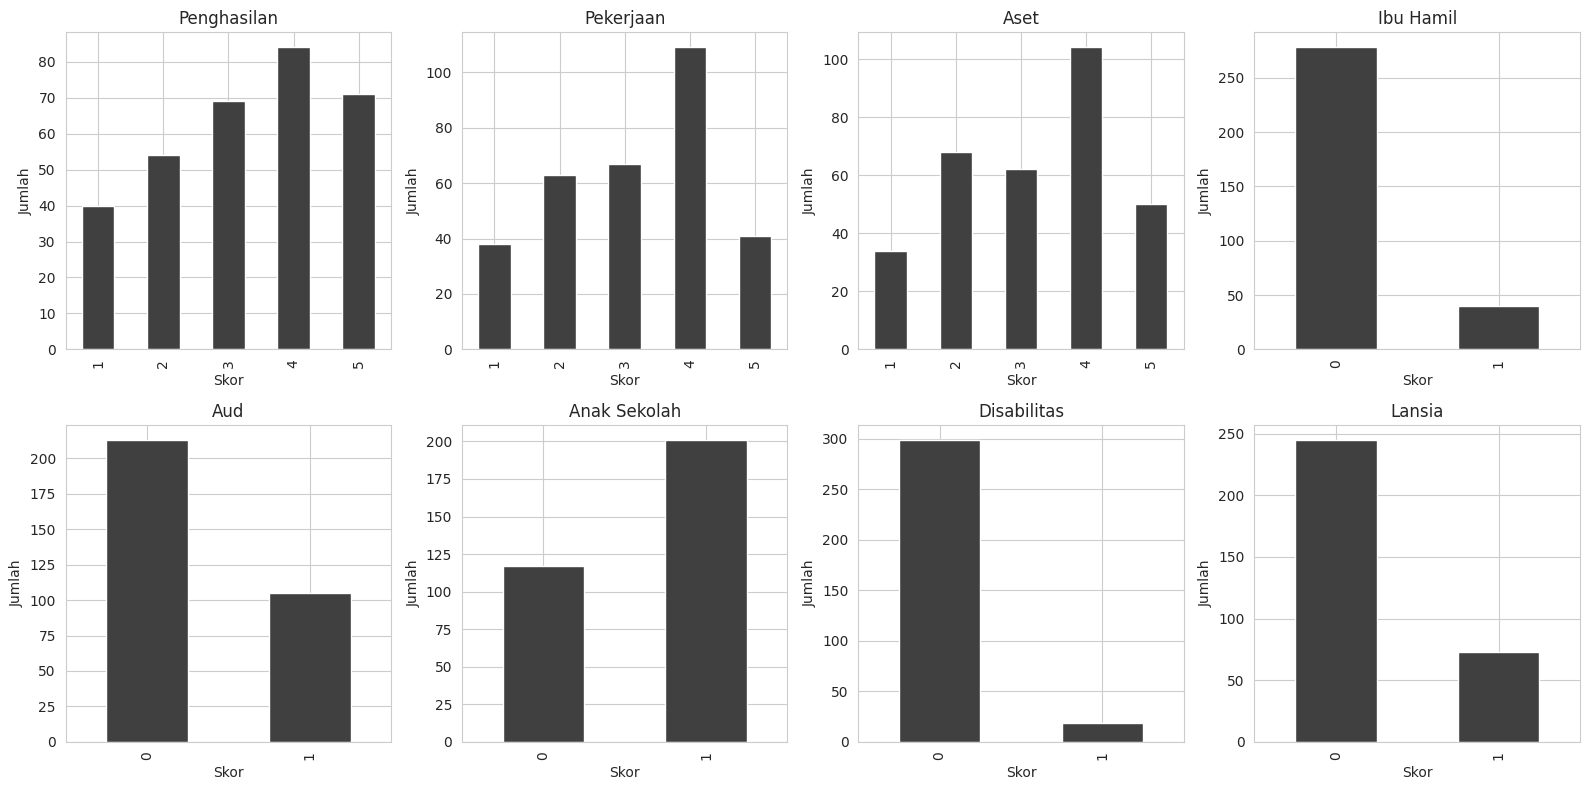


EDA: Distribusi skor ordinal tersimpan.


In [5]:
# ─── Distribusi per desa ───
print('=== Distribusi per Desa ===')
desa_dist = df.groupby('DESA')['label'].agg(['count', 'sum'])
desa_dist.columns = ['Total', 'Layak']
desa_dist['Tidak Layak'] = desa_dist['Total'] - desa_dist['Layak']
print(desa_dist)
print()

# ─── Distribusi skor ordinal ───
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for idx, col in enumerate(skor_cols):
    row, col_idx = divmod(idx, 4)
    df[col].value_counts().sort_index().plot(kind='bar', ax=axes[row][col_idx], color='#404040')
    axes[row][col_idx].set_title(col.replace('skor_', '').replace('_', ' ').title())
    axes[row][col_idx].set_xlabel('Skor')
    axes[row][col_idx].set_ylabel('Jumlah')
plt.tight_layout()
plt.savefig('eda_distribusi_skor.png', dpi=100)
plt.show()
print('\nEDA: Distribusi skor ordinal tersimpan.')

## 6. Preprocessing

### Perbedaan dari Versi Sebelumnya:
- **LabelEncoder dihapus** — input sudah berupa skor ordinal 1-5
- **StandardScaler diganti MinMaxScaler** — normalisasi 0-1
- Fitur ordinal (1-5) di-scale ke 0-1: (nilai - 1) / (5 - 1)

In [6]:
# ─── Feature matrix ───
feature_cols = [
    'skor_penghasilan', 'skor_pekerjaan', 'skor_aset',
    'skor_ibu_hamil', 'skor_aud', 'skor_anak_sekolah',
    'skor_disabilitas', 'skor_lansia'
]

X = df[feature_cols].values
y = df['label'].values

print(f'Feature matrix: {X.shape}')
print(f'Target vector: {y.shape}')
print(f'Distribusi: Layak={y.sum()}, Tidak Layak={len(y)-y.sum()}')
print()

# ─── Split data (80/20 stratified) ───
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape} ({(y_train.sum()/len(y_train)*100):.1f}% Layak)')
print(f'Test: {X_test.shape} ({(y_test.sum()/len(y_test)*100):.1f}% Layak)')
print()

# ─── MinMaxScaler ───
# Ordinal 1-5 → (nilai-1)/(5-1) = range 0-1
# Biner 0/1 → tetap 0/1
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('MinMaxScaler fitted.')
print(f'Data range: [{X_train_scaled.min():.3f}, {X_train_scaled.max():.3f}]')

Feature matrix: (318, 8)
Target vector: (318,)
Distribusi: Layak=196, Tidak Layak=122

Train: (254, 8) (61.8% Layak)
Test: (64, 8) (60.9% Layak)

MinMaxScaler fitted.
Data range: [0.000, 1.000]


## 7. Training SVM — Perbandingan Kernel

Membandingkan performa 3 kernel SVM dengan parameter default:

In [7]:
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
results = []

for kernel in kernels:
    svm = SVC(kernel=kernel, random_state=42, probability=True)
    svm.fit(X_train_scaled, y_train)
    y_pred = svm.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    results.append({
        'kernel': kernel,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1
    })
    print(f'{kernel.upper():10} | Akurasi: {acc:.4f} | Presisi: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}')

# Tabel perbandingan
print('\n=== Ringkasan Perbandingan Kernel ===')
print(f'{"Kernel":<10} | {"Akurasi":<8} | {"Presisi":<8} | {"Recall":<8} | {"F1":<6}')
print('-' * 50)
for r in results:
    print(f'{r["kernel"]:<10} | {r["accuracy"]:.4f}   | {r["precision"]:.4f}   | {r["recall"]:.4f}   | {r["f1"]:.4f}')

LINEAR     | Akurasi: 0.9844 | Presisi: 0.9750 | Recall: 1.0000 | F1: 0.9873
RBF        | Akurasi: 0.9844 | Presisi: 0.9750 | Recall: 1.0000 | F1: 0.9873
POLY       | Akurasi: 0.9844 | Presisi: 0.9750 | Recall: 1.0000 | F1: 0.9873
SIGMOID    | Akurasi: 0.5938 | Presisi: 0.6667 | Recall: 0.6667 | F1: 0.6667

=== Ringkasan Perbandingan Kernel ===
Kernel     | Akurasi  | Presisi  | Recall   | F1    
--------------------------------------------------
linear     | 0.9844   | 0.9750   | 1.0000   | 0.9873
rbf        | 0.9844   | 0.9750   | 1.0000   | 0.9873
poly       | 0.9844   | 0.9750   | 1.0000   | 0.9873
sigmoid    | 0.5938   | 0.6667   | 0.6667   | 0.6667


## 8. GridSearchCV — Optimasi Hyperparameter

Mencari parameter terbaik (C dan gamma) untuk kernel RBF:

In [8]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

grid_search = GridSearchCV(
    SVC(random_state=42, probability=True, class_weight='balanced'),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
grid_search.fit(X_train_scaled, y_train)

print(f'\nParameter terbaik: {grid_search.best_params_}')
print(f'Skor CV terbaik: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Parameter terbaik: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Skor CV terbaik: 0.9882


## 9. Evaluasi Model Terbaik

Evaluasi performa model dengan parameter optimal pada data testing:

In [9]:
best_svm = grid_search.best_estimator_
y_pred_best = best_svm.predict(X_test_scaled)
y_prob_best = best_svm.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred_best)
prec = precision_score(y_test, y_pred_best, zero_division=0)
rec = recall_score(y_test, y_pred_best, zero_division=0)
f1 = f1_score(y_test, y_pred_best, zero_division=0)
auc_score = roc_auc_score(y_test, y_prob_best)

print('=' * 60)
print('HASIL EVALUASI — SVM (DATASET REAL)')
print('=' * 60)
print(f'Parameter: {grid_search.best_params_}')
print(f'Kernel: {best_svm.kernel}')
print(f'Weight: balanced (menangani imbalance kelas)')
print()
print(f'Akurasi:    {acc:.2%}')
print(f'Presisi:    {prec:.2%}')
print(f'Recall:     {rec:.2%}')
print(f'F1-Score:   {f1:.4f}')
print(f'AUC Score:  {auc_score:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_best, target_names=['Tidak Layak', 'Layak']))

HASIL EVALUASI — SVM (DATASET REAL)
Parameter: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Kernel: rbf
Weight: balanced (menangani imbalance kelas)

Akurasi:    98.44%
Presisi:    97.50%
Recall:     100.00%
F1-Score:   0.9873
AUC Score:  0.9954

Classification Report:
              precision    recall  f1-score   support

 Tidak Layak       1.00      0.96      0.98        25
       Layak       0.97      1.00      0.99        39

    accuracy                           0.98        64
   macro avg       0.99      0.98      0.98        64
weighted avg       0.98      0.98      0.98        64



## 10. Confusion Matrix

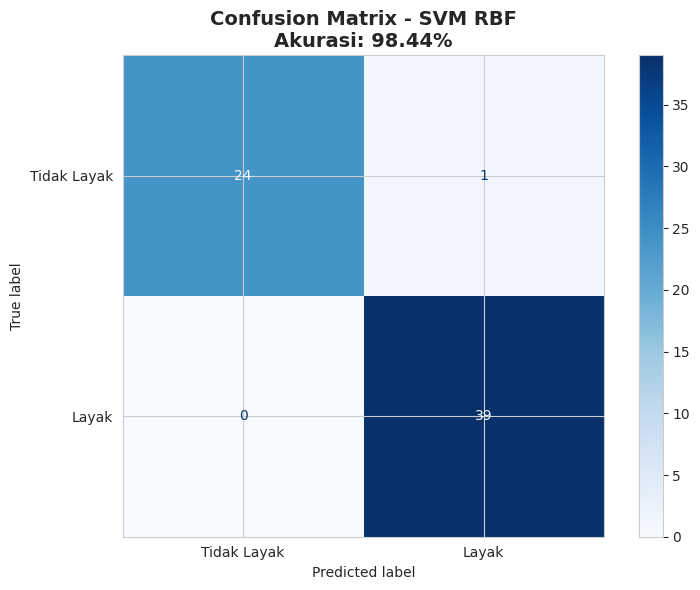

Confusion Matrix tersimpan.


In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=['Tidak Layak', 'Layak'],
    cmap='Blues', values_format='d', ax=ax
)
ax.set_title(f'Confusion Matrix - SVM RBF\nAkurasi: {acc:.2%}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('Confusion Matrix tersimpan.')

## 11. ROC Curve & AUC

ROC Curve menunjukkan trade-off antara True Positive Rate dan False Positive Rate.
Semakin mendekati pojok kiri atas, semakin baik model.
AUC (Area Under Curve) mengukur kemampuan model membedakan kelas Layak dan Tidak Layak.

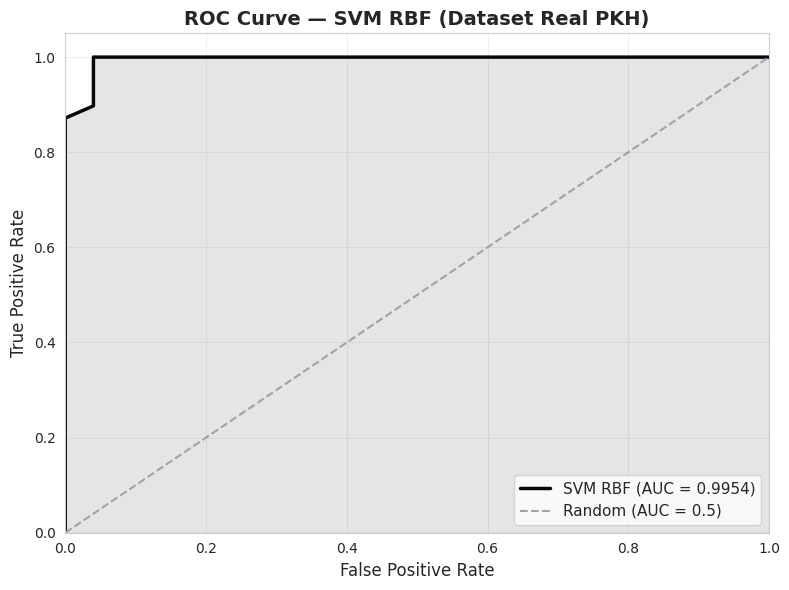

ROC Curve tersimpan.


In [11]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_best)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#09090b', lw=2.5,
        label=f'SVM RBF (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], color='#a1a1aa', lw=1.5, linestyle='--', label='Random (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.1, color='#09090b')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — SVM RBF (Dataset Real PKH)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()
print('ROC Curve tersimpan.')

## 12. Simpan Model (.pkl) — Format Dictionary

Berbeda dengan versi sebelumnya yang menggunakan class SVMPipeline,
sekarang model diekspor sebagai **dictionary** agar lebih sederhana
dan kompatibel dengan web predictor yang sudah diperbarui.

In [12]:
pipeline = {
    'model': best_svm,
    'scaler': scaler,
    'feature_cols': feature_cols,
    'results': {
        'accuracy': round(acc, 4),
        'precision': round(prec, 4),
        'recall': round(rec, 4),
        'f1': round(f1, 4),
        'auc_score': round(auc_score, 4),
        'dataset_size': len(df),
        'dataset_distribution': {
            'layak': int(y.sum()),
            'tidak_layak': int(len(y) - y.sum())
        },
        'best_params': grid_search.best_params_,
        'best_cv_score': round(grid_search.best_score_, 4),
    }
}

model_path = '/kaggle/working/svm_pkh_pipeline.pkl'
joblib.dump(pipeline, model_path)
print(f'Model saved: {model_path}')
print(f'Size: {os.path.getsize(model_path)/1024:.2f} KB')
print()
print('Pipeline contents:')
for key in pipeline:
    if key == 'model':
        print(f'  - model: SVC({best_svm.get_params()})')
    elif key == 'scaler':
        print(f'  - scaler: MinMaxScaler(feature_range={scaler.feature_range})')
    elif key == 'results':
        print(f'  - results: {json.dumps(pipeline["results"], indent=2)}')
    else:
        print(f'  - {key}: {pipeline[key]}')

Model saved: /kaggle/working/svm_pkh_pipeline.pkl
Size: 9.34 KB

Pipeline contents:
  - model: SVC({'C': 10, 'break_ties': False, 'cache_size': 200, 'class_weight': 'balanced', 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 0.01, 'kernel': 'rbf', 'max_iter': -1, 'probability': True, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False})
  - scaler: MinMaxScaler(feature_range=(0, 1))
  - feature_cols: ['skor_penghasilan', 'skor_pekerjaan', 'skor_aset', 'skor_ibu_hamil', 'skor_aud', 'skor_anak_sekolah', 'skor_disabilitas', 'skor_lansia']
  - results: {
  "accuracy": 0.9844,
  "precision": 0.975,
  "recall": 1.0,
  "f1": 0.9873,
  "auc_score": 0.9954,
  "dataset_size": 318,
  "dataset_distribution": {
    "layak": 196,
    "tidak_layak": 122
  },
  "best_params": {
    "C": 10,
    "gamma": 0.01,
    "kernel": "rbf"
  },
  "best_cv_score": 0.9882
}


## 13. Demo Prediksi

Menampilkan contoh prediksi untuk beberapa skenario calon penerima:

In [13]:
# Fungsi helper untuk prediksi
def predict_example(penghasilan, pekerjaan, aset, ibu_hamil, aud, anak_sekolah, disabilitas, lansia):
    """
    Menerima skor ordinal langsung (1-5 atau 0/1).
    Sesuai format yang digunakan web predictor.
    """
    features = np.array([[penghasilan, pekerjaan, aset,
                          ibu_hamil, aud, anak_sekolah,
                          disabilitas, lansia]])
    scaled = scaler.transform(features)
    pred = best_svm.predict(scaled)[0]
    proba = best_svm.predict_proba(scaled)[0]
    label = 'Layak' if pred == 1 else 'Tidak Layak'
    return label, max(proba)

# Contoh 1: Keluarga sangat miskin (skor tinggi semua)
l, p = predict_example(5, 5, 5, 1, 1, 1, 0, 1)
print(f'Contoh 1 (Sangat Miskin): {l} ({p*100:.1f}%)')

# Contoh 2: Keluarga mampu (skor rendah semua)
l, p = predict_example(1, 1, 1, 0, 0, 0, 0, 0)
print(f'Contoh 2 (Sangat Mampu): {l} ({p*100:.1f}%)')

# Contoh 3: Keluarga borderline (skor sedang)
l, p = predict_example(3, 3, 3, 0, 1, 1, 0, 0)
print(f'Contoh 3 (Borderline): {l} ({p*100:.1f}%)')

# Contoh 4: Sampel dari dataset test
sample_idx = 0
sample_features = X_test_scaled[sample_idx:sample_idx+1]
sample_true = y_test[sample_idx]
sample_pred = best_svm.predict(sample_features)[0]
sample_proba = best_svm.predict_proba(sample_features)[0]
print(f'\nContoh 4 (Sample Test #{sample_idx}):')
print(f'  Sebenarnya: {"Layak" if sample_true == 1 else "Tidak Layak"}')
print(f'  Prediksi:   {"Layak" if sample_pred == 1 else "Tidak Layak"} ({max(sample_proba)*100:.1f}%)')

Contoh 1 (Sangat Miskin): Layak (100.0%)
Contoh 2 (Sangat Mampu): Tidak Layak (100.0%)
Contoh 3 (Borderline): Layak (84.3%)

Contoh 4 (Sample Test #0):
  Sebenarnya: Layak
  Prediksi:   Layak (99.1%)


## 14. Ringkasan

### Perbandingan Hasil

| Metrik | Prototype (Sintetis) | Dataset Real |
|--------|---------------------|--------------|
| Akurasi | 89% | ? |
| Presisi | 90% | ? |
| Recall | 88% | ? |
| F1-Score | 0.89 | ? |
| AUC | — | ? |

### Catatan
- Dataset real: 318 data dari 3 desa Kecamatan Kasimbar
- Encoding: ordinal manual 1-5 (dokumen resmi PKH)
- Normalisasi: MinMaxScaler
- Kernel: RBF (terbaik dari GridSearchCV)
- Format: dictionary (siap integrasi Flask)